In [1]:
import pandas as pd

df = pd.read_excel("Coffee Shop Sales (1).xlsx")

print(df.shape)
print(df.head())
df.info()
print(df.isnull().sum())

(149116, 11)
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                 

In [2]:
# 1. Check nulls and duplicates
print(df.isnull().sum().sum(), "total nulls")
print(df.duplicated().sum(), "duplicate rows")

# 2. Combine date and time into one datetime column
df["datetime"] = pd.to_datetime(
    df["transaction_date"].astype(str) + " " + df["transaction_time"].astype(str)
)

# 3. Create new columns
df["revenue"] = df["transaction_qty"] * df["unit_price"]
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.day_name()

# 4. Check date range, stores and summary statistics
print(df["datetime"].min(), "to", df["datetime"].max())
print(df["store_location"].unique())
print(df[["transaction_qty", "unit_price", "revenue"]].describe())

0 total nulls
0 duplicate rows
2023-01-01 07:06:11 to 2023-06-30 20:57:19
<ArrowStringArray>
['Lower Manhattan', 'Hell's Kitchen', 'Astoria']
Length: 3, dtype: str
       transaction_qty     unit_price        revenue
count    149116.000000  149116.000000  149116.000000
mean          1.438276       3.382219       4.686367
std           0.542509       2.658723       4.227099
min           1.000000       0.800000       0.800000
25%           1.000000       2.500000       3.000000
50%           1.000000       3.000000       3.750000
75%           2.000000       3.750000       6.000000
max           8.000000      45.000000     360.000000


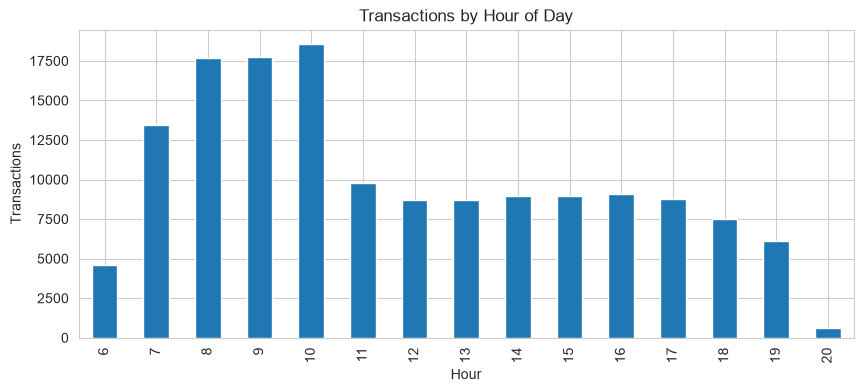

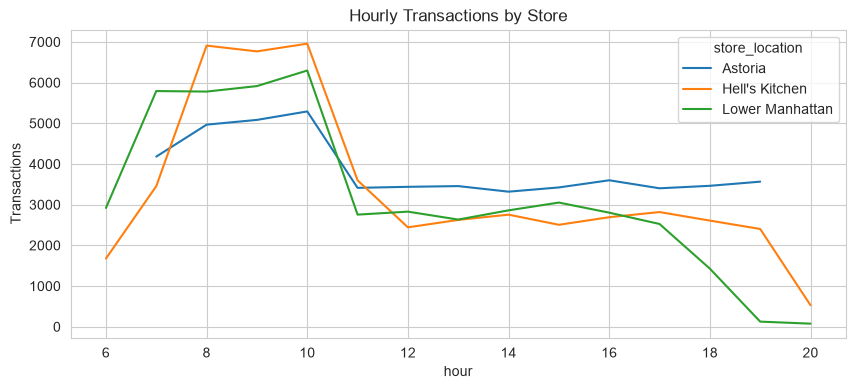

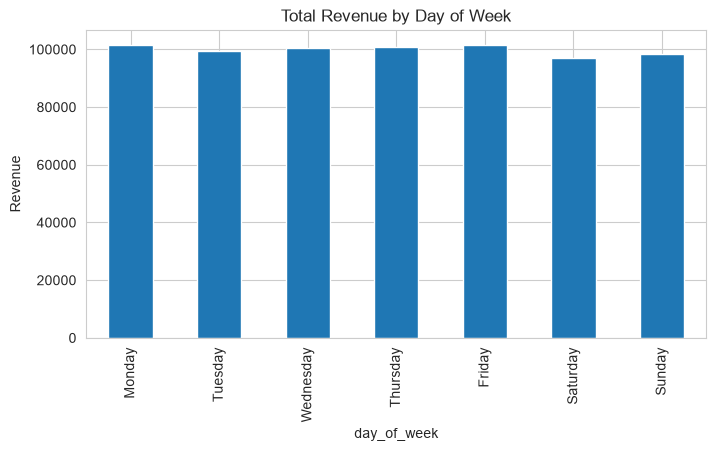

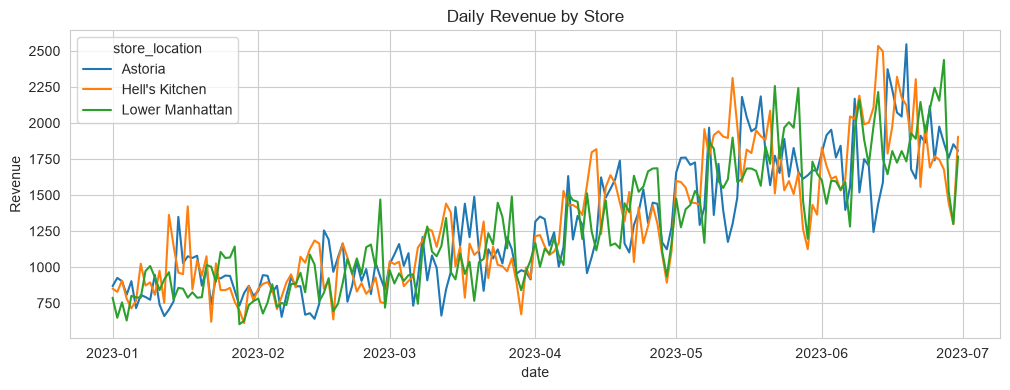

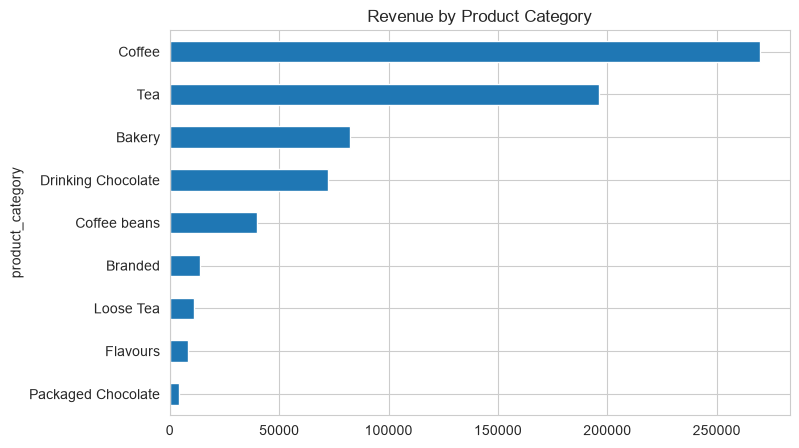

                  datetime  store_location product_category product_detail  \
133337 2023-06-17 10:41:11  Hell's Kitchen     Coffee beans      Civet Cat   
148702 2023-06-30 11:18:31  Hell's Kitchen     Coffee beans      Civet Cat   
133407 2023-06-17 11:18:31  Hell's Kitchen     Coffee beans      Civet Cat   
68981  2023-04-17 11:18:31  Hell's Kitchen     Coffee beans      Civet Cat   
97979  2023-05-17 09:05:20  Hell's Kitchen     Coffee beans      Civet Cat   
9365   2023-01-17 09:55:47  Hell's Kitchen     Coffee beans      Civet Cat   
9310   2023-01-17 09:05:20  Hell's Kitchen     Coffee beans      Civet Cat   
68806  2023-04-17 09:55:47  Hell's Kitchen     Coffee beans      Civet Cat   
98275  2023-05-17 11:18:31  Hell's Kitchen     Coffee beans      Civet Cat   
133186 2023-06-17 09:55:47  Hell's Kitchen     Coffee beans      Civet Cat   

        transaction_qty  unit_price  revenue  
133337                8        45.0    360.0  
148702                8        45.0    360.0  


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Hourly demand: total transactions per hour of day
hourly = df.groupby("hour")["transaction_id"].count()
hourly.plot(kind="bar", figsize=(10, 4), title="Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

# 2. Hourly demand by store (line chart)
hourly_store = df.groupby(["hour", "store_location"])["transaction_id"].count().unstack()
hourly_store.plot(figsize=(10, 4), title="Hourly Transactions by Store")
plt.ylabel("Transactions")
plt.show()

# 3. Day-of-week pattern
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df.groupby("day_of_week")["revenue"].sum().reindex(order)
dow.plot(kind="bar", figsize=(8, 4), title="Total Revenue by Day of Week")
plt.ylabel("Revenue")
plt.show()

# 4. Daily revenue trend per store
daily = df.groupby(["date", "store_location"])["revenue"].sum().unstack()
daily.plot(figsize=(12, 4), title="Daily Revenue by Store")
plt.ylabel("Revenue")
plt.show()

# 5. Revenue share by product category
df.groupby("product_category")["revenue"].sum().sort_values().plot(
    kind="barh", figsize=(8, 5), title="Revenue by Product Category"
)
plt.show()

# 6. Check the outlier rows (very high revenue)
print(df.sort_values("revenue", ascending=False)[
    ["datetime", "store_location", "product_category", "product_detail",
     "transaction_qty", "unit_price", "revenue"]
].head(10))

In [4]:
# 1. Operating hours of each store (min and max hour with sales)
hours_range = df.groupby("store_location")["hour"].agg(["min", "max"])
print(hours_range)

# 2. Hourly aggregation per store
hourly_ts = (
    df.groupby([df["datetime"].dt.floor("h"), "store_location"])
      .agg(transactions=("transaction_id", "count"),
           quantity=("transaction_qty", "sum"),
           revenue=("revenue", "sum"))
      .reset_index()
)

# 3. Build a continuous hourly index within each store's operating hours
start = df["datetime"].min().normalize()
end = df["datetime"].max().normalize() + pd.Timedelta(hours=23)
full_index = pd.date_range(start, end, freq="h")

parts = []
for store, g in hourly_ts.groupby("store_location"):
    h_min, h_max = hours_range.loc[store]
    idx = full_index[(full_index.hour >= h_min) & (full_index.hour <= h_max)]
    g = g.set_index("datetime")[["transactions", "quantity", "revenue"]]
    g = g.reindex(idx, fill_value=0)   # missing hours inside opening time = zero sales
    g["store_location"] = store
    g.index.name = "datetime"
    parts.append(g.reset_index())

hourly_full = pd.concat(parts, ignore_index=True)

# 4. Daily aggregation per store (built from the complete hourly data)
daily_full = (
    hourly_full.set_index("datetime")
    .groupby("store_location")
    .resample("D")[["transactions", "quantity", "revenue"]]
    .sum()
    .reset_index()
)

# 5. Sanity checks
print(hourly_full.shape, daily_full.shape)
print("Expected daily rows:", df["datetime"].dt.date.nunique() * 3)
print("Zero-sales hours filled:", (hourly_full["transactions"] == 0).sum())
print(daily_full.head())

# 6. Save for later steps and the Streamlit app
hourly_full.to_csv("hourly_ts.csv", index=False)
daily_full.to_csv("daily_ts.csv", index=False)

                 min  max
store_location           
Astoria            7   19
Hell's Kitchen     6   20
Lower Manhattan    6   20
(7783, 5) (543, 5)
Expected daily rows: 543
Zero-sales hours filled: 920
  store_location   datetime  transactions  quantity  revenue
0        Astoria 2023-01-01           190       277   868.40
1        Astoria 2023-01-02           212       301   925.50
2        Astoria 2023-01-03           205       287   902.75
3        Astoria 2023-01-04           187       262   808.25
4        Astoria 2023-01-05           198       285   903.05


In [5]:
# ---------- HOURLY FEATURES ----------
# 1. Full 24h grid per store so that lag_24 means exactly 24 hours back
full_idx = pd.date_range(
    hourly_full["datetime"].min().normalize(),
    hourly_full["datetime"].max().normalize() + pd.Timedelta(hours=23),
    freq="h",
)

parts = []
for store, g in hourly_full.groupby("store_location"):
    s = g.set_index("datetime")["transactions"].reindex(full_idx)  # NaN = store closed
    f = pd.DataFrame({"transactions": s})
    f["lag_1"] = s.shift(1)
    f["lag_24"] = s.shift(24)
    f["lag_168"] = s.shift(168)
    # Rolling means use shift(1) so the current value is never included (no leakage)
    f["roll_24"] = s.shift(1).rolling(24, min_periods=12).mean()
    f["roll_168"] = s.shift(1).rolling(168, min_periods=84).mean()
    f["store_location"] = store
    f = f[f["transactions"].notna()]  # keep only operating hours
    parts.append(f)

hourly_feat = pd.concat(parts).rename_axis("datetime").reset_index()

# 2. Calendar features
hourly_feat["hour"] = hourly_feat["datetime"].dt.hour
hourly_feat["dayofweek"] = hourly_feat["datetime"].dt.dayofweek
hourly_feat["is_weekend"] = (hourly_feat["dayofweek"] >= 5).astype(int)
hourly_feat["day_index"] = (hourly_feat["datetime"] - hourly_feat["datetime"].min()).dt.days

# 3. Store dummy variables (keep the original column for per-store evaluation)
hourly_feat = hourly_feat.join(
    pd.get_dummies(hourly_feat["store_location"], prefix="store", dtype=int)
)

# 4. Drop the first 7 days (lag_168 is not available there)
hourly_feat = hourly_feat.dropna(subset=["lag_168"]).reset_index(drop=True)

# ---------- DAILY FEATURES ----------
dparts = []
for store, g in daily_full.groupby("store_location"):
    g = g.sort_values("datetime").copy()
    g["lag_1"] = g["revenue"].shift(1)
    g["lag_7"] = g["revenue"].shift(7)
    g["roll_3"] = g["revenue"].shift(1).rolling(3).mean()
    g["roll_7"] = g["revenue"].shift(1).rolling(7).mean()
    dparts.append(g)

daily_feat = pd.concat(dparts, ignore_index=True)
daily_feat["dayofweek"] = daily_feat["datetime"].dt.dayofweek
daily_feat["is_weekend"] = (daily_feat["dayofweek"] >= 5).astype(int)
daily_feat["day_index"] = (daily_feat["datetime"] - daily_feat["datetime"].min()).dt.days
daily_feat = daily_feat.join(
    pd.get_dummies(daily_feat["store_location"], prefix="store", dtype=int)
)
daily_feat = daily_feat.dropna(subset=["lag_7", "roll_7"]).reset_index(drop=True)

# ---------- CHECKS AND SAVE ----------
print(hourly_feat.shape, daily_feat.shape)
print(hourly_feat.head(3).T)
print(hourly_feat.isnull().sum())

hourly_feat.to_csv("hourly_features.csv", index=False)
daily_feat.to_csv("daily_features.csv", index=False)

(7482, 15) (522, 15)
                                         0                    1  \
datetime               2023-01-08 07:00:00  2023-01-08 08:00:00   
transactions                           6.0                 17.0   
lag_1                                  NaN                  6.0   
lag_24                                19.0                 21.0   
lag_168                                0.0                  0.0   
roll_24                          14.153846            13.153846   
roll_168                         14.593407            14.659341   
store_location                     Astoria              Astoria   
hour                                     7                    8   
dayofweek                                6                    6   
is_weekend                               1                    1   
day_index                                7                    7   
store_Astoria                            1                    1   
store_Hell's Kitchen                     

In [6]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Time-based split: last 28 days are the test set
split_date = daily_full["datetime"].max() - pd.Timedelta(days=27)
train = daily_full[daily_full["datetime"] < split_date]
test = daily_full[daily_full["datetime"] >= split_date]
print("Train:", train["datetime"].min().date(), "to", train["datetime"].max().date())
print("Test :", test["datetime"].min().date(), "to", test["datetime"].max().date())

# 2. Metric function
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# 3. Baseline forecasts per store (using only training data)
rows = []
pred_records = []

for store in daily_full["store_location"].unique():
    tr = train[train["store_location"] == store].sort_values("datetime")["revenue"].values
    te = test[test["store_location"] == store].sort_values("datetime")
    y = te["revenue"].values
    n = len(y)

    forecasts = {
        "Naive": np.repeat(tr[-1], n),                      # last known value
        "Seasonal Naive (7d)": np.resize(tr[-7:], n),       # repeat last week
        "Moving Average (7d)": np.repeat(tr[-7:].mean(), n) # mean of last 7 days
    }

    for model, f in forecasts.items():
        mae, rmse, mape = evaluate(y, f)
        rows.append([store, model, mae, rmse, mape])
        for d, a, p in zip(te["datetime"], y, f):
            pred_records.append([d, store, model, a, p])

baseline_results = pd.DataFrame(rows, columns=["store", "model", "MAE", "RMSE", "MAPE_%"])
baseline_preds = pd.DataFrame(pred_records, columns=["datetime", "store", "model", "actual", "forecast"])

# 4. Results per store and average across stores
print(baseline_results.round(2))
print(baseline_results.groupby("model")[["MAE", "RMSE", "MAPE_%"]].mean().round(2))

Train: 2023-01-01 to 2023-06-02
Test : 2023-06-03 to 2023-06-30
             store                model     MAE    RMSE  MAPE_%
0          Astoria                Naive  240.90  300.10   14.06
1          Astoria  Seasonal Naive (7d)  247.74  316.20   13.09
2          Astoria  Moving Average (7d)  242.87  315.19   12.80
3   Hell's Kitchen                Naive  296.52  369.37   14.63
4   Hell's Kitchen  Seasonal Naive (7d)  489.64  592.01   24.48
5   Hell's Kitchen  Moving Average (7d)  441.99  524.94   21.45
6  Lower Manhattan                Naive  417.62  483.41   21.36
7  Lower Manhattan  Seasonal Naive (7d)  403.60  466.65   21.51
8  Lower Manhattan  Moving Average (7d)  281.95  352.27   14.49
                        MAE    RMSE  MAPE_%
model                                      
Moving Average (7d)  322.27  397.47   16.25
Naive                318.35  384.29   16.68
Seasonal Naive (7d)  380.33  458.29   19.69


In [7]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.ensemble import GradientBoostingRegressor

stores = daily_full["store_location"].unique()
rows, pred_records, prophet_ci = [], [], []

def log_result(store, model, dates, y, f):
    mae, rmse, mape = evaluate(y, f)
    rows.append([store, model, mae, rmse, mape])
    for d, a, p in zip(dates, y, f):
        pred_records.append([d, store, model, a, p])

# ---------- Statistical models and Prophet (one model per store) ----------
for store in stores:
    tr_df = train[train["store_location"] == store].sort_values("datetime")
    te_df = test[test["store_location"] == store].sort_values("datetime")
    tr = tr_df.set_index("datetime")["revenue"].asfreq("D")
    y = te_df["revenue"].values
    dates = te_df["datetime"].tolist()
    n = len(y)

    # 1. Exponential Smoothing (damped trend + weekly seasonality)
    ets = ExponentialSmoothing(tr, trend="add", damped_trend=True,
                               seasonal="add", seasonal_periods=7).fit()
    log_result(store, "Exp Smoothing", dates, y, ets.forecast(n).values)

    # 2. SARIMA with weekly seasonality
    sarima = SARIMAX(tr, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit(disp=False)
    log_result(store, "SARIMA", dates, y, sarima.forecast(n).values)

    # 3. Prophet (no yearly seasonality because data covers only 6 months)
    dfp = pd.DataFrame({"ds": tr.index, "y": tr.values})
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True,
                daily_seasonality=False, interval_width=0.95)
    m.fit(dfp)
    fc = m.predict(m.make_future_dataframe(periods=n)).tail(n)
    log_result(store, "Prophet", dates, y, fc["yhat"].values)
    ci = fc[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
    ci["store"] = store
    prophet_ci.append(ci)

# ---------- Gradient Boosting (one global model, recursive forecast) ----------
store_cols = [c for c in daily_feat.columns
              if c.startswith("store_") and c != "store_location"]
features = ["lag_1", "lag_7", "roll_3", "roll_7", "dayofweek", "is_weekend"] + store_cols

gb_train = daily_feat[daily_feat["datetime"] < split_date]
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                               max_depth=3, random_state=42)
gb.fit(gb_train[features], gb_train["revenue"])

for store in stores:
    hist = list(train[train["store_location"] == store].sort_values("datetime")["revenue"])
    te_df = test[test["store_location"] == store].sort_values("datetime")
    preds = []
    for d in te_df["datetime"]:
        row = {
            "lag_1": hist[-1],
            "lag_7": hist[-7],
            "roll_3": np.mean(hist[-3:]),
            "roll_7": np.mean(hist[-7:]),
            "dayofweek": d.dayofweek,
            "is_weekend": int(d.dayofweek >= 5),
        }
        for c in store_cols:
            row[c] = int(c == f"store_{store}")
        p = gb.predict(pd.DataFrame([row])[features])[0]
        preds.append(p)
        hist.append(p)  # predicted value becomes the lag for the next day
    log_result(store, "Gradient Boosting", te_df["datetime"].tolist(),
               te_df["revenue"].values, np.array(preds))

# ---------- Combine with baselines and compare ----------
adv_results = pd.DataFrame(rows, columns=["store", "model", "MAE", "RMSE", "MAPE_%"])
all_results = pd.concat([baseline_results, adv_results], ignore_index=True)
all_preds = pd.concat([
    baseline_preds,
    pd.DataFrame(pred_records, columns=["datetime", "store", "model", "actual", "forecast"]),
], ignore_index=True)

print(all_results.groupby("model")[["MAE", "RMSE", "MAPE_%"]].mean().sort_values("MAPE_%").round(2))
print(all_results.pivot(index="model", columns="store", values="MAPE_%").round(2))

# ---------- Save for the Streamlit app ----------
all_results.to_csv("model_results.csv", index=False)
all_preds.to_csv("daily_predictions.csv", index=False)
pd.concat(prophet_ci).to_csv("prophet_intervals.csv", index=False)

11:36:38 - cmdstanpy - INFO - Chain [1] start processing
11:36:38 - cmdstanpy - INFO - Chain [1] done processing
11:36:39 - cmdstanpy - INFO - Chain [1] start processing
11:36:39 - cmdstanpy - INFO - Chain [1] done processing
11:36:39 - cmdstanpy - INFO - Chain [1] start processing
11:36:39 - cmdstanpy - INFO - Chain [1] done processing


                        MAE    RMSE  MAPE_%
model                                      
SARIMA               274.02  347.81   14.08
Prophet              253.62  308.24   14.25
Exp Smoothing        291.12  357.44   15.39
Gradient Boosting    318.67  391.91   16.23
Moving Average (7d)  322.27  397.47   16.25
Naive                318.35  384.29   16.68
Seasonal Naive (7d)  380.33  458.29   19.69
store                Astoria  Hell's Kitchen  Lower Manhattan
model                                                        
Exp Smoothing          16.25           15.06            14.85
Gradient Boosting      14.62           13.46            20.61
Moving Average (7d)    12.80           21.45            14.49
Naive                  14.06           14.63            21.36
Prophet                15.27           14.70            12.77
SARIMA                 12.13           16.06            14.06
Seasonal Naive (7d)    13.09           24.48            21.51


Hourly train rows: 7181 | test rows: 301
Seasonal Naive (lag_168)   MAE=12.21  RMSE=17.74  WAPE=45.7%
Gradient Boosting          MAE=8.07  RMSE=11.42  WAPE=30.2%
Peak thresholds (transactions/hour):
store_location
Astoria            32.0
Hell's Kitchen     28.0
Lower Manhattan    28.0
Name: transactions, dtype: float64

 Seasonal Naive - overall
Peak Capture %       58.8
Peak Error Rate %    41.2
False Alarm %        35.6
dtype: float64
Seasonal Naive - per store
                 Peak Capture %  Peak Error Rate %  False Alarm %
store_location                                                   
Astoria                    36.4               63.6           54.3
Hell's Kitchen             73.3               26.7           29.0
Lower Manhattan            72.5               27.5           23.7

 Gradient Boosting - overall
Peak Capture %       52.6
Peak Error Rate %    47.4
False Alarm %        31.8
dtype: float64
Gradient Boosting - per store
                 Peak Capture %  Peak Error Rate 

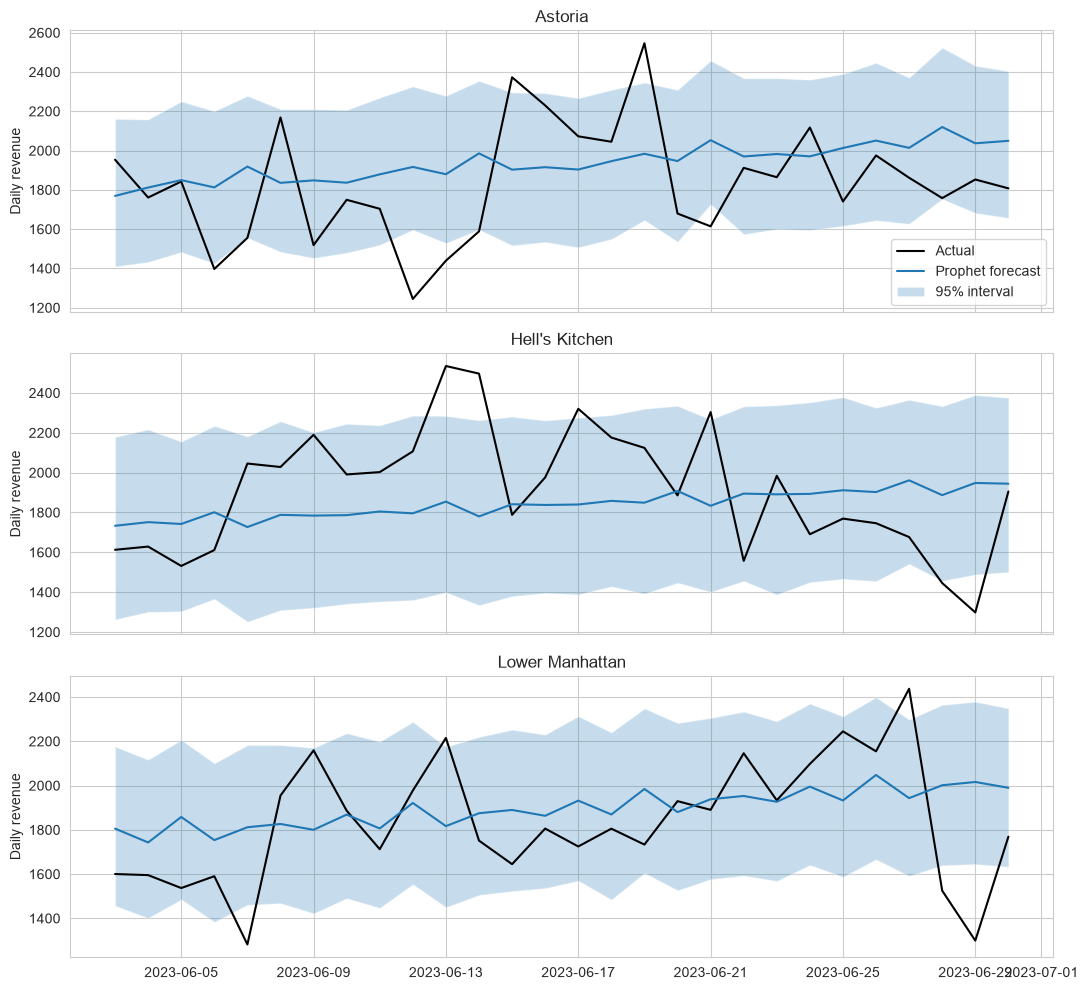

In [8]:
# 1. Hourly split: last 7 days are the test set
h_split = hourly_feat["datetime"].max().normalize() - pd.Timedelta(days=6)
h_train = hourly_feat[hourly_feat["datetime"] < h_split]
h_test = hourly_feat[hourly_feat["datetime"] >= h_split].copy()
print("Hourly train rows:", len(h_train), "| test rows:", len(h_test))

# 2. Features (only lag_168 is truly known up to 7 days ahead)
h_store_cols = [c for c in hourly_feat.columns
                if c.startswith("store_") and c != "store_location"]
h_features = ["lag_168", "hour", "dayofweek", "is_weekend", "day_index"] + h_store_cols

# 3. Gradient Boosting for hourly transactions
gb_h = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                 max_depth=4, random_state=42)
gb_h.fit(h_train[h_features], h_train["transactions"])
h_test["pred_gb"] = np.clip(gb_h.predict(h_test[h_features]), 0, None)
h_test["pred_snaive"] = h_test["lag_168"]  # same hour last week (baseline)

# 4. Hourly accuracy (WAPE is used instead of MAPE because some hours have zero sales)
for name, col in [("Seasonal Naive (lag_168)", "pred_snaive"), ("Gradient Boosting", "pred_gb")]:
    err = h_test["transactions"] - h_test[col]
    mae = err.abs().mean()
    rmse = np.sqrt((err ** 2).mean())
    wape = err.abs().sum() / h_test["transactions"].sum() * 100
    print(f"{name:26s} MAE={mae:.2f}  RMSE={rmse:.2f}  WAPE={wape:.1f}%")

# 5. Peak definition: hour in the top 20% of the store's training transactions
thr = h_train.groupby("store_location")["transactions"].quantile(0.80)
h_test["thr"] = h_test["store_location"].map(thr)
h_test["actual_peak"] = h_test["transactions"] >= h_test["thr"]
print("Peak thresholds (transactions/hour):")
print(thr.round(1))

def peak_metrics(g, col):
    pred_peak = g[col] >= g["thr"]
    act = g["actual_peak"]
    capture = (act & pred_peak).sum() / max(act.sum(), 1)
    false_alarm = (~act & pred_peak).sum() / max(pred_peak.sum(), 1)
    return pd.Series({"Peak Capture %": capture * 100,
                      "Peak Error Rate %": (1 - capture) * 100,
                      "False Alarm %": false_alarm * 100})

for name, col in [("Seasonal Naive", "pred_snaive"), ("Gradient Boosting", "pred_gb")]:
    print("\n", name, "- overall")
    print(peak_metrics(h_test, col).round(1))
    print(name, "- per store")
    print(h_test.groupby("store_location").apply(lambda g: peak_metrics(g, col)).round(1))

# 6. Prophet forecast with 95% confidence interval for each store
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
ci_all = pd.concat(prophet_ci)
for ax, store in zip(axes, stores):
    ci = ci_all[ci_all["store"] == store]
    act = test[test["store_location"] == store].sort_values("datetime")
    ax.plot(act["datetime"], act["revenue"], label="Actual", color="black")
    ax.plot(ci["ds"], ci["yhat"], label="Prophet forecast", color="tab:blue")
    ax.fill_between(ci["ds"], ci["yhat_lower"], ci["yhat_upper"], alpha=0.25, label="95% interval")
    ax.set_title(store)
    ax.set_ylabel("Daily revenue")
axes[0].legend()
plt.tight_layout()
plt.show()

# 7. Save for the Streamlit app
h_test.to_csv("hourly_predictions.csv", index=False)

In [9]:
# 1. Trend-aware peak threshold: top 20% of the last 28 training days per store
recent = h_train[h_train["datetime"] >= h_split - pd.Timedelta(days=28)]
thr2 = recent.groupby("store_location")["transactions"].quantile(0.80)
h_test["thr"] = h_test["store_location"].map(thr2)
h_test["actual_peak"] = h_test["transactions"] >= h_test["thr"]
print(thr2.round(1))
print("Actual peak hours in test:", h_test["actual_peak"].sum(), "of", len(h_test))

# 2. Try different cutoffs for calling a predicted peak
def peak_scores(g, col, factor):
    pred_peak = g[col] >= factor * g["thr"]
    act = g["actual_peak"]
    capture = (act & pred_peak).sum() / max(act.sum(), 1) * 100
    false_alarm = (~act & pred_peak).sum() / max(pred_peak.sum(), 1) * 100
    return capture, 100 - capture, false_alarm

rows_p = []
for name, col in [("Seasonal Naive", "pred_snaive"), ("Gradient Boosting", "pred_gb")]:
    for factor in [1.0, 0.9, 0.8, 0.7]:
        c, e, f = peak_scores(h_test, col, factor)
        rows_p.append([name, factor, c, e, f])

peak_table = pd.DataFrame(rows_p, columns=["model", "cutoff_factor",
                                           "Peak Capture %", "Peak Error Rate %", "False Alarm %"])
print(peak_table.round(1))

# 3. Prophet interval coverage: how often actual revenue falls inside the 95% interval
ci_all = pd.concat(prophet_ci)
actual = test[["datetime", "store_location", "revenue"]].rename(
    columns={"datetime": "ds", "store_location": "store"})
cov = ci_all.merge(actual, on=["ds", "store"])
cov["inside"] = (cov["revenue"] >= cov["yhat_lower"]) & (cov["revenue"] <= cov["yhat_upper"])
print(cov.groupby("store")["inside"].mean().mul(100).round(1))
print("Overall coverage %:", round(cov["inside"].mean() * 100, 1))

# 4. Save updated outputs for the Streamlit app
h_test.to_csv("hourly_predictions.csv", index=False)
peak_table.to_csv("peak_results.csv", index=False)

store_location
Astoria            45.0
Hell's Kitchen     37.0
Lower Manhattan    39.2
Name: transactions, dtype: float64
Actual peak hours in test: 45 of 301
               model  cutoff_factor  Peak Capture %  Peak Error Rate %  \
0     Seasonal Naive            1.0            75.6               24.4   
1     Seasonal Naive            0.9            82.2               17.8   
2     Seasonal Naive            0.8            86.7               13.3   
3     Seasonal Naive            0.7            91.1                8.9   
4  Gradient Boosting            1.0            91.1                8.9   
5  Gradient Boosting            0.9            93.3                6.7   
6  Gradient Boosting            0.8            95.6                4.4   
7  Gradient Boosting            0.7            97.8                2.2   

   False Alarm %  
0           52.1  
1           51.9  
2           56.2  
3           63.4  
4           37.9  
5           44.0  
6           47.6  
7           50.0  
sto

11:36:44 - cmdstanpy - INFO - Chain [1] start processing
11:36:44 - cmdstanpy - INFO - Chain [1] done processing
11:36:45 - cmdstanpy - INFO - Chain [1] start processing
11:36:45 - cmdstanpy - INFO - Chain [1] done processing
11:36:45 - cmdstanpy - INFO - Chain [1] start processing
11:36:45 - cmdstanpy - INFO - Chain [1] done processing


                ensemble         
                    mean      sum
store                            
Astoria           1983.0  59491.0
Hell's Kitchen    1856.0  55695.0
Lower Manhattan   1970.0  59103.0
Next 7 days total forecast revenue:
 store
Astoria            13523.0
Hell's Kitchen     12652.0
Lower Manhattan    13445.0
Name: ensemble, dtype: float64
Next 30 days total, all stores: 174288


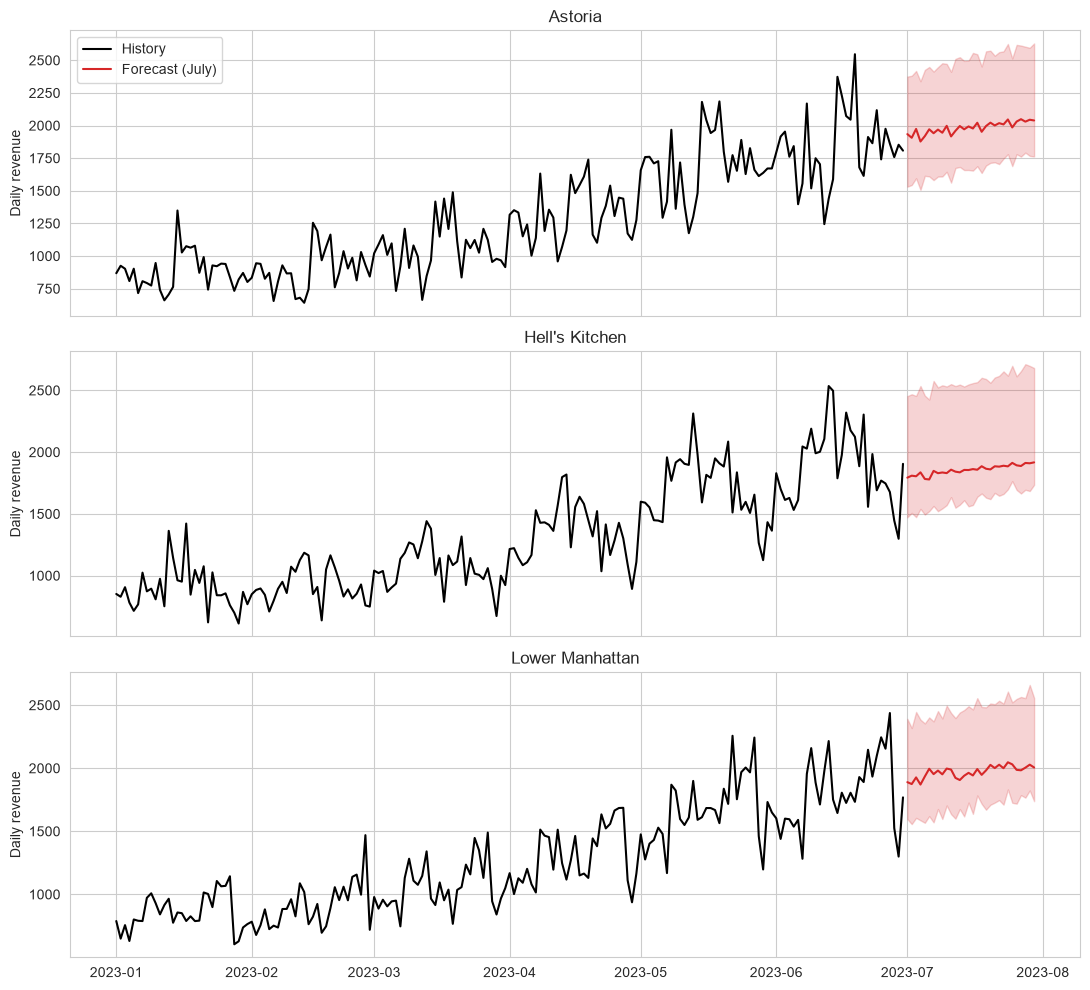

In [10]:
# Final forecast: retrain on ALL data and predict the next 30 days (1 to 30 July 2023)
H = 30
future_rows = []

for store in stores:
    full = daily_full[daily_full["store_location"] == store].sort_values("datetime")
    s = full.set_index("datetime")["revenue"].asfreq("D")

    # SARIMA
    sar = SARIMAX(s, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit(disp=False)
    f_sar = sar.forecast(H)

    # Prophet with 95% interval
    dfp = pd.DataFrame({"ds": s.index, "y": s.values})
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True,
                daily_seasonality=False, interval_width=0.95)
    m.fit(dfp)
    fc = m.predict(m.make_future_dataframe(periods=H)).tail(H).reset_index(drop=True)

    out = pd.DataFrame({
        "date": f_sar.index,
        "store": store,
        "sarima": f_sar.values,
        "prophet": fc["yhat"].values,
        "prophet_lower": fc["yhat_lower"].values,
        "prophet_upper": fc["yhat_upper"].values,
    })
    out["ensemble"] = (out["sarima"] + out["prophet"]) / 2
    out["horizon"] = np.where(np.arange(H) < 7, "Short-term (1-7d)", "Medium-term (8-30d)")
    future_rows.append(out)

future = pd.concat(future_rows, ignore_index=True)
future.to_csv("future_forecast.csv", index=False)

# Summary tables for the report
print(future.groupby("store")[["ensemble"]].agg(["mean", "sum"]).round(0))
week1 = future[future["date"] < "2023-07-08"].groupby("store")["ensemble"].sum().round(0)
print("Next 7 days total forecast revenue:\n", week1)
print("Next 30 days total, all stores:", round(future["ensemble"].sum()))

# Chart: history + forecast
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, store in zip(axes, stores):
    h = daily_full[daily_full["store_location"] == store]
    f = future[future["store"] == store]
    ax.plot(h["datetime"], h["revenue"], color="black", label="History")
    ax.plot(f["date"], f["ensemble"], color="tab:red", label="Forecast (July)")
    ax.fill_between(f["date"], f["prophet_lower"], f["prophet_upper"], alpha=0.2, color="tab:red")
    ax.set_title(store)
    ax.set_ylabel("Daily revenue")
axes[0].legend()
plt.tight_layout()
plt.show()

In [11]:
import os
os.makedirs("figures", exist_ok=True)

def save(fig, name):
    fig.savefig(f"figures/{name}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

# Figure 1: transactions by hour of day
fig, ax = plt.subplots(figsize=(9, 4))
df.groupby("hour")["transaction_id"].count().plot(kind="bar", ax=ax, color="#6B4F3A")
ax.set_title("Transactions by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Transactions")
save(fig, "fig1_hourly_transactions")

# Figure 2: hourly transactions by store
fig, ax = plt.subplots(figsize=(9, 4))
df.groupby(["hour", "store_location"])["transaction_id"].count().unstack().plot(ax=ax)
ax.set_title("Hourly Transactions by Store")
ax.set_ylabel("Transactions")
save(fig, "fig2_hourly_by_store")

# Figure 3: daily revenue by store
fig, ax = plt.subplots(figsize=(11, 4))
daily_full.pivot(index="datetime", columns="store_location", values="revenue").plot(ax=ax)
ax.set_title("Daily Revenue by Store")
ax.set_ylabel("Revenue")
save(fig, "fig3_daily_revenue")

# Figure 4: revenue by product category
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("product_category")["revenue"].sum().sort_values().plot(kind="barh", ax=ax, color="#6B4F3A")
ax.set_title("Revenue by Product Category")
save(fig, "fig4_category_revenue")

# Figure 5: Prophet forecast with 95% interval on the test period
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
ci_all = pd.concat(prophet_ci)
for ax, store in zip(axes, stores):
    ci = ci_all[ci_all["store"] == store]
    act = test[test["store_location"] == store].sort_values("datetime")
    ax.plot(act["datetime"], act["revenue"], label="Actual", color="black")
    ax.plot(ci["ds"], ci["yhat"], label="Prophet forecast", color="tab:blue")
    ax.fill_between(ci["ds"], ci["yhat_lower"], ci["yhat_upper"], alpha=0.25, label="95% interval")
    ax.set_title(store)
    ax.set_ylabel("Daily revenue")
axes[0].legend()
fig.tight_layout()
save(fig, "fig5_prophet_interval")

# Figure 6: history and July forecast
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, store in zip(axes, stores):
    h = daily_full[daily_full["store_location"] == store]
    f = future[future["store"] == store]
    ax.plot(h["datetime"], h["revenue"], color="black", label="History")
    ax.plot(f["date"], f["ensemble"], color="tab:red", label="Forecast (July)")
    ax.fill_between(f["date"], f["prophet_lower"], f["prophet_upper"], alpha=0.2, color="tab:red")
    ax.set_title(store)
    ax.set_ylabel("Daily revenue")
axes[0].legend()
fig.tight_layout()
save(fig, "fig6_july_forecast")

print(os.listdir("figures"))

['fig1_hourly_transactions.png', 'fig2_hourly_by_store.png', 'fig3_daily_revenue.png', 'fig4_category_revenue.png', 'fig5_prophet_interval.png', 'fig6_july_forecast.png']
